# Request Characteristics EDA

This notebook explores response time by request characteristics, GPU usage, and workflow latency.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Inspection

In [17]:
df = pd.read_csv("../cleanup/Olena_Log_Template_Proposed.csv")
df.head()

,chat_id,test_id,scenario_name,scenario_purpose,how_to_start,input_type,model,image_input,text_input,model_output,...,error_message,cpu_per_second_pct,cpu_avg_pct,gpu_per_second_pct,gpu_avg_pct,memory_per_second_mb,memory_avg_mb,throughput_per_minute,throughput_per_second,notes
0,1475432104,1,Text Input - Model A,Test response and processing time for text-onl...,Trigger n8n via Telegram bot with plain text i...,Text Only,minicpm-o-2_6,...,/promptText Analyze the tone of this product r...,The tone in this statement can be classified a...,...,NaN,"[67,67,67,67,67]",67.00,"[0,4,4,5,5]",3.60,"[6947,7012,7019,7022,7034]",7007.0,12.03,0.2004,NaN
1,1475432104,2,Text Input - Model B,Same as #1 but using Model B to compare perfor...,Trigger n8n via Telegram bot with plain text i...,Text Only,gemma-3-12b-it,...,/promptText Analyze the tone of this product r...,The tone of this review is **Neutral**.\n\nHer...,...,NaN,"[67,67,67,67,67,67,67,67,67,67,67,67,68,68,68,...",67.29,"[5,2,1,2,2,3,3,3,3,3,3,2,2,2,2,3,2]",2.53,"[7052,7134,7124,7124,7117,7117,7125,7129,7119,...",7104.0,3.40,0.0566,NaN
2,1475432104,3,Text Input - Model C,Same as #1 but using Model C,Trigger n8n via Telegram bot with plain text i...,Text Only,pixtral-12b,...,/promptText Analyze the tone of this product r...,The tone of this product review can be classif...,...,NaN,"[68,68,68,68,68,68,68,68]",68.00,"[2,3,3,2,2,2,2,2]",2.25,"[7097,7152,7167,7156,7134,7142,7142,7137]",7141.0,7.10,0.1183,NaN
3,1475432104,4,Text Input - Model D,Same as #1 but using Model D,Trigger n8n via Telegram bot with plain text i...,Text Only,qwen2-vl-7b-instruct,...,/promptText Analyze the tone of this product r...,The tone of this product review can be classif...,...,NaN,"[68,68,68,68,68]",68.00,"[3,4,4,5,5]",4.20,"[7138,7194,7197,7203,7197]",7186.0,12.54,0.2091,NaN
4,1475432104,5,Text+Image Input - Model A,Test text + image input handling by Model A,Upload text+image via Telegram bot or webhook ...,Text + Image,minicpm-o-2_6,/9j/4AAQSkZJRgABAQEASABIAAD/2wBDAAQDAwQDAwQEAw...,/generateImageText Describe the scene in detai...,The image depicts an outdoor setting where sev...,...,NaN,"[68,68,68,68,68,68,68,68,69,69]",68.20,"[0,62,3,4,5,5,5,5,5,5]",9.90,"[7206,7285,7288,7293,7289,7291,7306,7298,7298,...",7285.0,5.75,0.0958,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   chat_id                     600 non-null    int64  
 1   test_id                     600 non-null    int64  
 2   scenario_name               600 non-null    str    
 3   scenario_purpose            600 non-null    str    
 4   how_to_start                600 non-null    str    
 5   input_type                  600 non-null    str    
 6   model                       600 non-null    str    
 7   image_input                 584 non-null    str    
 8   text_input                  584 non-null    str    
 9   model_output                472 non-null    str    
 10  workflow_name               600 non-null    str    
 11  workflow_start_time         460 non-null    str    
 12  workflow_end_time           460 non-null    str    
 13  workflow_time_hhmmss        460 non-null    st

In [ ]:
df.shape

(600, 30)

# Response Time by Request Characteristics

The analysis below examines successful model runs and compares model response time across different request/input types.

In [12]:
# Keep only successful model runs.
# Failed or not-executed requests do not have valid response-time measurements,
# so they should not be included in the response-time analysis

df_success = df[df["success"] == "Yes"].copy()

# Check the size of the filtered dataset.
df_success.shape

(460, 30)

In [13]:
# Count the number of successful requests in each input type.
# This gives the frequency distribution for the categorical variable input_type.

df_success["input_type"].value_counts()

input_type
Mixed           312
Text Only       116
Text + Image     16
Image Only       16
Name: count, dtype: int64

In [14]:
# Calculate the relative frequency (percentage) of each input type.
# normalize=True converts counts into proportions, and multiplying by 100
# converts them into percentages.

(df_success["input_type"].value_counts(normalize=True) * 100).round(1)

input_type
Mixed           67.8
Text Only       25.2
Text + Image     3.5
Image Only       3.5
Name: proportion, dtype: float64

In [15]:
# Calculate descriptive statistics for model response time
# grouped by request/input type.
# The table includes count, mean, standard deviation, minimum,
# quartiles, median, and maximum.

df_success.groupby("input_type")["model_time_seconds"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
input_type,,,,,,,,
Image Only,16.0,32.38,25.91,5.0,11.5,28.5,50.0,99.0
Mixed,312.0,34.20,38.48,2.0,11.0,22.0,37.0,200.0
Text + Image,16.0,47.94,59.45,10.0,16.0,28.5,55.0,246.0
Text Only,116.0,39.64,45.36,2.0,12.0,22.0,50.5,211.0


### Initial observations

The dataset is unbalanced across request types. Mixed requests represent the largest
group (67.8% of successful runs), while Text + Image and Image Only requests each
represent only 3.5%.

Text + Image requests have the highest mean response time (47.94 seconds), followed
by Text Only (39.64 seconds), Mixed (34.20 seconds), and Image Only (32.38 seconds).

For all request types, the mean response time is higher than the median. The relatively
large standard deviations and high maximum values suggest that the response-time
distributions may be right-skewed and contain unusually long response times.
Because some request-type groups have small sample sizes, these comparisons should
be interpreted cautiously.

## Distribution of Response Time by Input Type

A boxplot is used to compare the distribution, median, spread, and potential outliers
of model response time across request types.

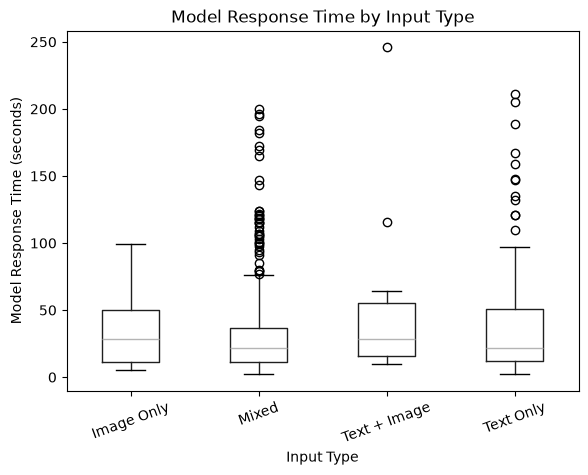

In [19]:
# Compare the distribution of model response time across input types.
# The boxplot shows the median, quartiles, overall spread, and potential outliers.

df_success.boxplot(
    column="model_time_seconds",
    by="input_type",
    grid=False
)

plt.title("Model Response Time by Input Type")
plt.suptitle("")
plt.xlabel("Input Type")
plt.ylabel("Model Response Time (seconds)")
plt.xticks(rotation=20)

plt.show()

Boxplot observations

The boxplot shows substantial variability in response time across all request types.
Mixed and Text Only requests contain several unusually long response times, while
Text + Image includes one particularly extreme observation near 246 seconds.

The upper outliers and the fact that mean response times are higher than the medians
suggest positively skewed response-time distributions. However, the request-type
groups are very different in size, particularly for Text + Image and Image Only,
so comparisons should be interpreted cautiously.

## Frequency of Successful Requests by Input Type

The bar chart below shows the number of successful model runs for each request/input type.

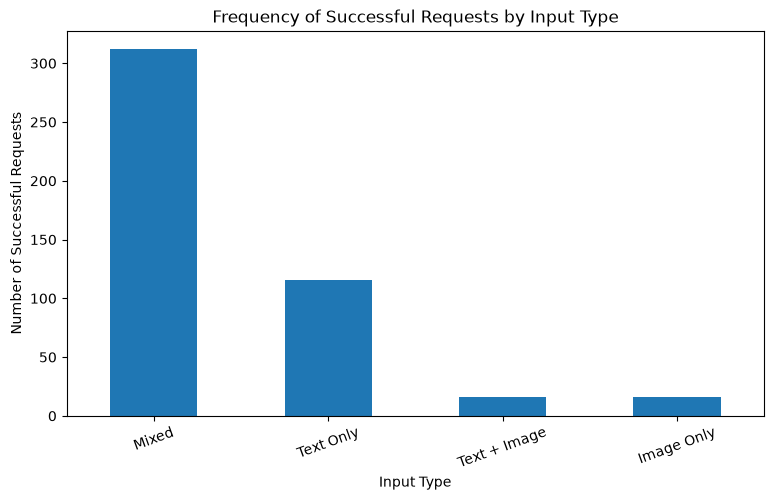

In [22]:
# Count successful requests in each input type.
input_type_counts = df_success["input_type"].value_counts()

# Create a bar chart of the frequency distribution.
input_type_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add labels and title.
plt.title("Frequency of Successful Requests by Input Type")
plt.xlabel("Input Type")
plt.ylabel("Number of Successful Requests")

# Rotate category labels slightly for readability.
plt.xticks(rotation=20)

plt.show()

### Frequency observations

The bar chart confirms that the successful runs are heavily concentrated in the Mixed and Text Only categories. Because the group sizes are highly unequal, response-time comparisons across input types should be interpreted cautiously.

## Additional Request Characteristics

In [23]:
# Inspect the available categories for additional request characteristics.
# This helps determine which variables are meaningful for further response-time comparisons.

print("how_to_start:")
print(df_success["how_to_start"].value_counts())

print("\nscenario_name:")
print(df_success["scenario_name"].value_counts())

print("\ntest_id:")
print(df_success["test_id"].value_counts().sort_index())

how_to_start:
how_to_start
Same as #13                                                                         189
Telegram message trigger                                                            108
Use google sheets (get row(s)) trigger for sequential requests.                      76
Run batch of text, text+image, image-only inputs via workflow trigger or script.     63
Upload text+image via Telegram bot or webhook.                                        6
Upload image-only input via Telegram bot or webhook.                                  6
Trigger n8n via Telegram bot with plain text input.                                   4
Trigger via webhook or bot with text input.                                           3
Upload text+image via Telegram bot or webhook file input with caption.                2
Upload image-only input via Telegram bot or webhook file input.                       2
Trigger n8n via webhook or Telegram bot with plain text input.                        1
Name:

The additional variables were reviewed before further analysis. `how_to_start` contains several test-specific procedural descriptions rather than consistent comparable categories. `scenario_name` and `test_id` also encode parts of the experimental design, including model identity in many scenarios. Therefore, they are not used as standalone grouping variables for response-time comparisons in this section to avoid mixing request characteristics with model effects.

## GPU Usage by Request Characteristics

The analysis below compares average GPU utilization across different request/input types for successful model runs.

In [24]:
# Calculate descriptive statistics for average GPU usage
# grouped by request/input type.
# gpu_avg_pct represents the average GPU utilization during each successful model call.

df_success.groupby("input_type")["gpu_avg_pct"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
input_type,,,,,,,,
Image Only,16.0,6.45,2.53,3.25,4.60,5.75,7.44,11.75
Mixed,312.0,5.21,2.70,2.00,3.75,4.58,6.07,26.25
Text + Image,16.0,5.81,1.92,3.19,4.20,5.48,7.01,9.90
Text Only,116.0,3.48,0.98,2.00,2.53,3.21,4.48,5.20


### Distribution of GPU Usage by Input Type

A boxplot is used to compare the distribution, median, spread, and potential outliers
of average GPU utilization across request types.

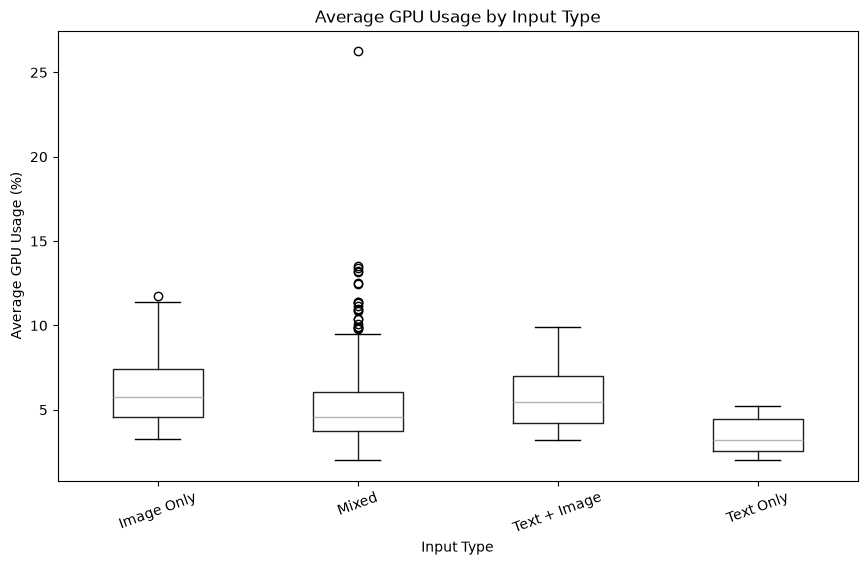

In [26]:
# Compare average GPU utilization across request/input types.

df_success.boxplot(
    column="gpu_avg_pct",
    by="input_type",
    figsize=(10, 6),
    grid=False
)

plt.title("Average GPU Usage by Input Type")
plt.suptitle("")
plt.xlabel("Input Type")
plt.ylabel("Average GPU Usage (%)")
plt.xticks(rotation=20)

plt.show()

### GPU Usage Observations

Image Only requests have the highest mean average GPU utilization (6.45%), followed by Text + Image (5.81%), Mixed (5.21%), and Text Only (3.48%).

Text Only requests show the lowest GPU utilization and the smallest variability. Mixed requests show greater variability and include several high GPU-usage observations, including an extreme value of 26.25%.

Because the request-type groups are highly unequal in size, especially for Image Only and Text + Image, these comparisons should be interpreted cautiously.

## Workflow Latency by Request Characteristics

Workflow latency represents the total elapsed time of a workflow rather than only the model response time. Some batch tests record workflow time cumulatively, so the analysis uses one observation per workflow instead of treating every row as an independent workflow duration.

In [27]:
# Create a workflow-level dataset with one observation per workflow.
# Some workflows contain multiple model calls or cumulative batch measurements,
# so using every original row would count the same workflow multiple times.
#
# workflow_start_time identifies a workflow run in this dataset.
# For each workflow, the maximum workflow_time_seconds represents
# the final recorded duration of that workflow.

workflow_df = (
    df_success
    .groupby(
        ["workflow_start_time", "workflow_name", "input_type"],
        as_index=False
    )
    .agg(
        workflow_time_seconds=("workflow_time_seconds", "max")
    )
)

# Check the number of independent workflow runs.
workflow_df.shape

(56, 4)

In [28]:
# Count the number of workflow runs for each input type.

workflow_df["input_type"].value_counts()

input_type
Text Only       29
Mixed           19
Text + Image     4
Image Only       4
Name: count, dtype: int64

### Descriptive Statistics for Workflow Latency

The table below summarizes total workflow duration across request/input types using one final duration per workflow.

In [29]:
# Calculate descriptive statistics for workflow latency
# grouped by request/input type.

workflow_df.groupby("input_type")["workflow_time_seconds"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
input_type,,,,,,,,
Image Only,4.0,136.25,44.95,95.0,100.25,131.5,167.5,187.0
Mixed,19.0,683.26,559.15,121.0,278.50,544.0,895.0,2120.0
Text + Image,4.0,200.25,117.45,97.0,111.25,177.5,266.5,349.0
Text Only,29.0,158.76,102.50,26.0,72.00,140.0,254.0,338.0


### Distribution of Workflow Latency by Input Type

A boxplot is used to compare workflow duration across request/input types.

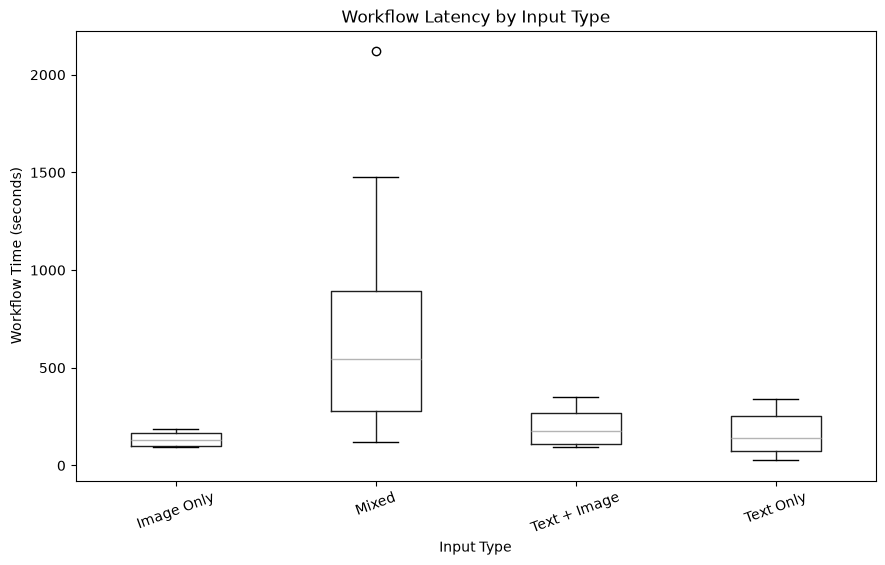

In [30]:
# Compare workflow latency across request/input types.

workflow_df.boxplot(
    column="workflow_time_seconds",
    by="input_type",
    figsize=(10, 6),
    grid=False
)

plt.title("Workflow Latency by Input Type")
plt.suptitle("")
plt.xlabel("Input Type")
plt.ylabel("Workflow Time (seconds)")
plt.xticks(rotation=20)

plt.show()

### Workflow Latency Observations

Mixed workflows show substantially longer and more variable total workflow durations than the other request types. The median workflow time for Mixed requests is 544 seconds, compared with 140 seconds for Text Only, 177.5 seconds for Text + Image, and 131.5 seconds for Image Only.

Mixed workflows also show the greatest variability, with a maximum duration of 2,120 seconds. However, Mixed requests in this dataset are associated with high-volume and batch-testing scenarios, so the observed difference should not be interpreted as an effect of input type alone.

The Text + Image and Image Only groups contain only four workflows each, so comparisons involving these categories should also be interpreted cautiously.

## EDA Summary

Among successful model runs, response time varies across request types, although the request-type groups are highly unequal in size. Text + Image requests show the highest mean model response time, while several request types contain unusually long response times and right-skewed distributions.

Average GPU utilization also differs across request types in this dataset, with Text Only requests showing the lowest average GPU usage.

At the workflow level, Mixed workflows show substantially longer and more variable durations. However, Mixed requests are associated with high-volume and batch-testing scenarios, so this difference cannot be attributed to input type alone.

These exploratory findings will be used to guide the statistical comparisons and modeling performed in the next stage of the project.